# EuroSAT 光谱图像预处理与指数计算

**目标**: 
该脚本将读取 `EuroSAT_MS` (多光谱) 数据集，并根据之前生成的 `train/valid/test.csv` 文件进行划分，然后计算并提取光谱指数作为特征。

**核心功能**:
1.  **加载已有的数据集划分**，确保与深度学习实验的可比性。
2.  读取多光谱 `.tif` 图像。
3.  计算 **NDVI** (归一化植被指数), **NDWI** (归一化水体指数), 和 **NDBI** (归一化建筑指数)。
4.  提取每个指数图像的统计特征（如平均值）。
5.  将提取的特征与标签一起保存到新的CSV文件中，用于后续的机器学习模型训练。
6.  通过可视化分析指数的有效性。

**依赖库**: 运行此脚本前，请确保已安装 `rasterio` (`pip install rasterio`)。

In [1]:
# 导入必要的库
import os
import pandas as pd
import numpy as np
import rasterio  # 用于读取多光谱 .tif 文件
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm # 用于显示美观的进度条
import json

## 1. 配置路径

请确保这里的路径与您的项目结构完全一致。

In [2]:
# --- 关键配置区 ---

# 包含 EuroSAT_MS 和 split_info 文件夹的父目录
# project_path = "F:/vscode project/IMA_PW3/EuroSat_classification-main_data_wx/"
project_path ="F:/vscode project/IMA_PW3/data"

# 多光谱图片文件夹路径 (注意是 EuroSAT_MS)
image_data_path = os.path.join(project_path, "EuroSAT_MS/").replace('\\', '/')

# 包含 train.csv, valid.csv, test.csv 的元数据文件夹路径
metadata_path = os.path.join(project_path, "split_info/").replace('\\', '/')

print(f"多光谱图片来源: {image_data_path}")
print(f"元数据 (CSV) 来源: {metadata_path}")

多光谱图片来源: F:/vscode project/IMA_PW3/data/EuroSAT_MS/
元数据 (CSV) 来源: F:/vscode project/IMA_PW3/data/split_info/


## 2. 定义波段映射和光谱指数计算函数

EuroSAT_MS 数据集包含13个波段。我们需要知道哪些波段对应于计算所需的光谱（如红光、近红外等）。

In [3]:
# EuroSAT 数据集的波段信息 (从0开始索引)
# B1: Coastal, B2: Blue, B3: Green, B4: Red
# B5-B7: Red Edge, B8: NIR, B8A: Narrow NIR
# B9: Water Vapour, B10: SWIR-Cirrus, B11: SWIR-1, B12: SWIR-2
BANDS = {
    'GREEN': 2, # 波段 3
    'RED': 3,   # 波段 4
    'NIR': 7,   # 波段 8
    'SWIR1': 10 # 波段 11
}

def calculate_ndvi(image_array):
    """计算归一化植被指数 (NDVI)"""
    # 公式: (NIR - Red) / (NIR + Red)
    nir = image_array[BANDS['NIR'], :, :].astype(float)
    red = image_array[BANDS['RED'], :, :].astype(float)
    
    numerator = nir - red
    denominator = nir + red
    
    # 加上一个很小的数 (epsilon) 来避免除以零的错误
    ndvi = np.divide(numerator, denominator, where=denominator!=0)
    return ndvi

def calculate_ndwi(image_array):
    """计算归一化水体指数 (NDWI)"""
    # 公式: (Green - NIR) / (Green + NIR)
    green = image_array[BANDS['GREEN'], :, :].astype(float)
    nir = image_array[BANDS['NIR'], :, :].astype(float)
    
    numerator = green - nir
    denominator = green + nir
    
    ndwi = np.divide(numerator, denominator, where=denominator!=0)
    return ndwi

def calculate_ndbi(image_array):
    """计算归一化建筑指数 (NDBI)"""
    # 公式: (SWIR1 - NIR) / (SWIR1 + NIR)
    swir1 = image_array[BANDS['SWIR1'], :, :].astype(float)
    nir = image_array[BANDS['NIR'], :, :].astype(float)
    
    numerator = swir1 - nir
    denominator = swir1 + nir
    
    ndbi = np.divide(numerator, denominator, where=denominator!=0)
    return ndbi

print("光谱指数计算函数定义完成。")

光谱指数计算函数定义完成。


## 3. 核心处理流程

这个函数将遍历一个给定的CSV文件（train, valid,或test），为每一行记录的图片计算光谱指数，并提取其平均值作为特征。

In [4]:
def process_split(split_df, image_base_path):
    """为给定的数据集DataFrame计算所有光谱指数特征。"""
    
    # 初始化用于存储新特征的列表
    ndvi_means, ndwi_means, ndbi_means = [], [], []

    # 使用 tqdm 显示进度条
    for index, row in tqdm(split_df.iterrows(), total=len(split_df)):
        # 构造完整的文件路径，注意要将 .jpg 替换为 .tif
        img_rel_path = row['ImagePath'].replace('.jpg', '.tif')
        img_abs_path = os.path.join(image_base_path, img_rel_path)

        try:
            with rasterio.open(img_abs_path) as src:
                image = src.read()

            # 计算所有指数
            ndvi = calculate_ndvi(image)
            ndwi = calculate_ndwi(image)
            ndbi = calculate_ndbi(image)

            # 提取每个指数的平均值作为特征，并添加到列表中
            ndvi_means.append(np.mean(ndvi))
            ndwi_means.append(np.mean(ndwi))
            ndbi_means.append(np.mean(ndbi))
        
        except Exception as e:
            print(f"\n错误：无法处理文件 {img_abs_path} - {e}")
            # 如果文件出错，用NaN填充，以保持数据对齐
            ndvi_means.append(np.nan)
            ndwi_means.append(np.nan)
            ndbi_means.append(np.nan)
    
    # 将新特征添加为DataFrame的新列
    split_df['NDVI_mean'] = ndvi_means
    split_df['NDWI_mean'] = ndwi_means
    split_df['NDBI_mean'] = ndbi_means
    
    return split_df

# --- 加载CSV文件 ---
train_df = pd.read_csv(os.path.join(metadata_path, 'train.csv'))
valid_df = pd.read_csv(os.path.join(metadata_path, 'valid.csv'))
test_df = pd.read_csv(os.path.join(metadata_path, 'test.csv'))

# --- 依次处理每个数据集 ---
print("正在处理训练集...")
train_features_df = process_split(train_df.copy(), image_data_path)

print("\n正在处理验证集...")
valid_features_df = process_split(valid_df.copy(), image_data_path)

print("\n正在处理测试集...")
test_features_df = process_split(test_df.copy(), image_data_path)

正在处理训练集...


  0%|          | 0/18899 [00:00<?, ?it/s]


正在处理验证集...


  0%|          | 0/4051 [00:00<?, ?it/s]


正在处理测试集...


  0%|          | 0/4050 [00:00<?, ?it/s]

## 4. 保存包含新特征的CSV文件

我们将把带有光谱指数特征的新DataFrame保存到 `split_info` 文件夹中，以便后续使用。

In [5]:
# 定义新文件的保存路径
train_features_path = os.path.join(metadata_path, 'train_features.csv')
valid_features_path = os.path.join(metadata_path, 'valid_features.csv')
test_features_path = os.path.join(metadata_path, 'test_features.csv')

print("\n正在保存带有光谱指数特征的CSV文件...")
train_features_df.to_csv(train_features_path, index=False)
valid_features_df.to_csv(valid_features_path, index=False)
test_features_df.to_csv(test_features_path, index=False)

print(f"- 训练集特征已保存到: {train_features_path}")
print(f"- 验证集特征已保存到: {valid_features_path}")
print(f"- 测试集特征已保存到: {test_features_path}")

# 显示训练集特征DataFrame的前几行以供检查
print("\n训练集特征预览:")
display(train_features_df.head())


正在保存带有光谱指数特征的CSV文件...
- 训练集特征已保存到: F:/vscode project/IMA_PW3/data/split_info/train_features.csv
- 验证集特征已保存到: F:/vscode project/IMA_PW3/data/split_info/valid_features.csv
- 测试集特征已保存到: F:/vscode project/IMA_PW3/data/split_info/test_features.csv

训练集特征预览:


,ImagePath,Label,NDVI_mean,NDWI_mean,NDBI_mean
0,Forest/Forest_904.jpg,1,0.789850,-0.648776,-0.381513
1,Pasture/Pasture_593.jpg,5,0.545290,-0.382639,-0.266399
2,PermanentCrop/PermanentCrop_2252.jpg,6,0.528772,-0.489389,-0.079064
3,AnnualCrop/AnnualCrop_394.jpg,0,0.503885,-0.476215,-0.180113
4,Residential/Residential_1142.jpg,7,0.475804,-0.396860,-0.122317


## 5. 可视化分析

现在我们已经提取了光谱指数特征，让我们通过可视化的方式，看看这些特征对于区分不同地物类别的效果如何。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13716\1492240042.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='ClassName', y='NDVI_mean', palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13716\1492240042.py:21: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13716\1492240042.py:21: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13716\1492240042.py:21: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13716\1492240042.py:21: UserWarning: Glyph 22343 (\N{CJK UNIFIE

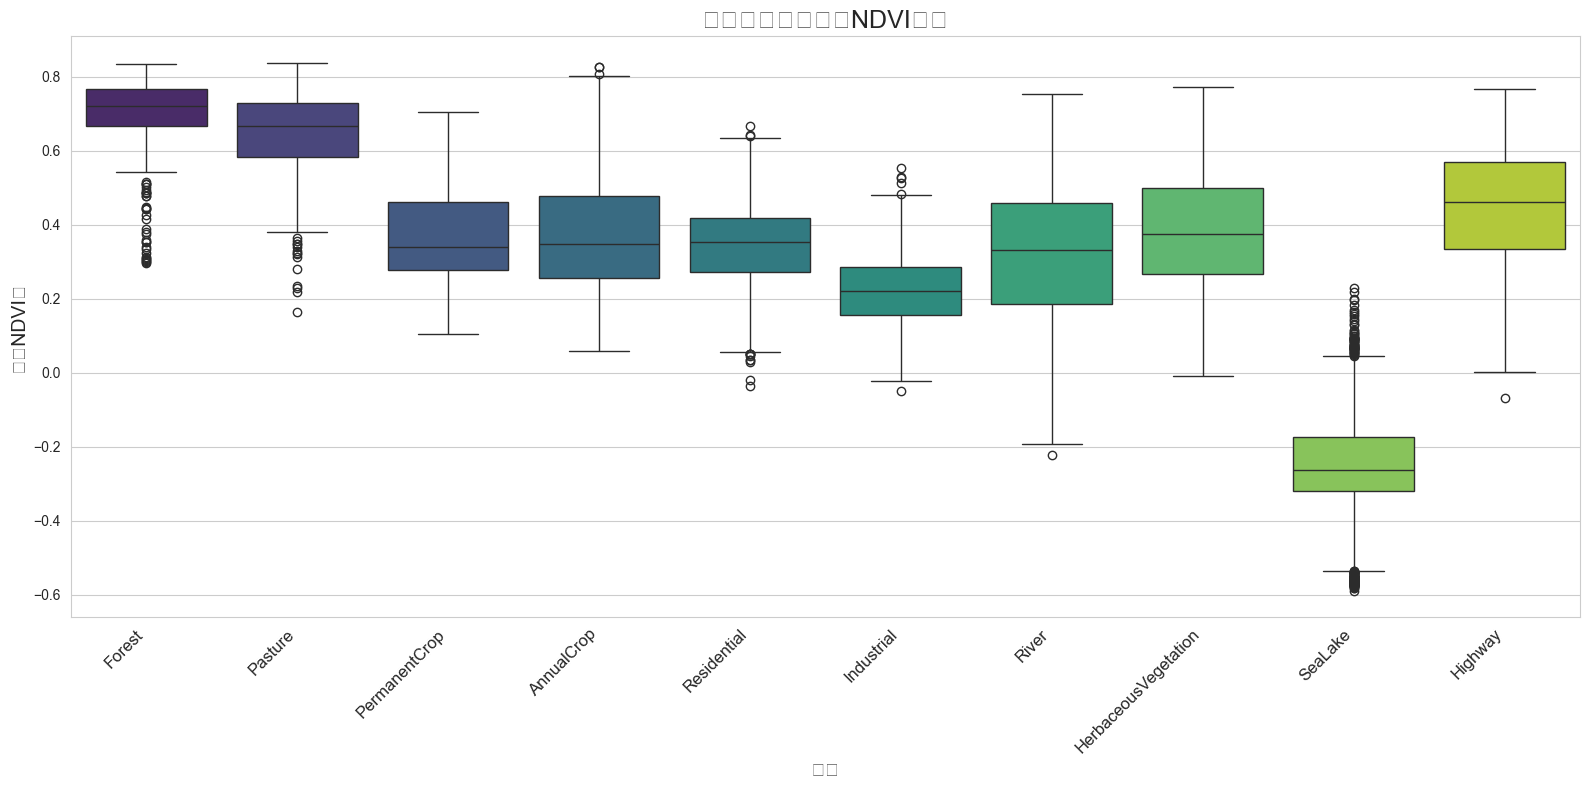

In [6]:
# --- 步骤 1: 加载标签映射文件，用于图表显示 ---
with open(os.path.join(metadata_path, 'label_map.json'), 'r') as f:
    label_to_index = json.load(f)
index_to_label = {v: k for k, v in label_to_index.items()}

# --- 步骤 2: 将数字标签转换为类别名称，方便阅读 ---
plot_df = train_features_df.copy()
plot_df['ClassName'] = plot_df['Label'].map(index_to_label)

# --- 步骤 3: 绘制箱形图 (Boxplot) ---
# 箱形图可以很好地展示一个特征（如NDVI_mean）在不同类别下的分布情况
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))
sns.boxplot(data=plot_df, x='ClassName', y='NDVI_mean', palette='viridis')

# 美化图表
plt.title('各类别地物的平均NDVI分布', fontsize=18)
plt.xlabel('类别', fontsize=14)
plt.ylabel('平均NDVI值', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

### 箱形图解读

- **NDVI (归一化植被指数)** 通常用于衡量植被的生长状况和覆盖度。值越高，表示植被越茂密。
- **观察上图**：
  - 像 `Forest` (森林) 和 `HerbaceousVegetation` (草地) 这样的类别，它们的NDVI值（箱体的位置）明显高于其他类别，说明NDVI是区分植被和非植被的强特征。
  - 像 `Industrial` (工业区), `Residential` (居民区), `Highway` (公路) 和 `SeaLake` (海洋湖泊) 这样的非植被类别，它们的NDVI值普遍较低。
- **结论**: 如果不同类别的箱体位置差异很大，且重叠部分较少，说明这个光谱指数特征对于分类任务是**非常有效**的。

--- 
**下一步**: 您现在可以使用 `train_features.csv`, `valid_features.csv`, `test_features.csv` 这三个文件来训练传统的机器学习模型，例如支持向量机(SVM)、随机森林(Random Forest)或XGBoost，并将它们的性能与您的深度学习模型进行比较。